In [1]:
from google.colab import drive
from google.colab import data_table

drive.mount('/content/drive')
data_table.enable_dataframe_formatter()
file_path = "/content/drive/MyDrive/Virtual Reality Lesson and Community Smells/Questionari/csv/"

Mounted at /content/drive


In [2]:
!pip install factor_analyzer
!pip install scikit_posthocs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42568 sha256=b86f50c303c58e135925fa4cc38b3442303db95dd817c64d7ea92e11c7ae6272
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from os import path
from scipy.stats import mannwhitneyu, kruskal
from factor_analyzer import FactorAnalyzer
import numpy as np
from sklearn.decomposition import PCA
import scikit_posthocs as sp

In [4]:
file_name = "dataset_for_test.csv"

variables = {
    "Learning Outcome": list(range(0, 13)),
    "Self Efficacy": list(range(13, 23)),
    "Immersiveness": list(range(23, 33)),
    "Affective Engagement": list(range(33, 38)),
    "Behavioral Engagement Compliance": list(range(38, 40)),
    "Behavioral Engagement Effort Class Participation": list(range(40, 44)),
    "Cognitive Engagement": list(range(44, 46)),
    "Disengagement": list(range(46, 49)),
    "Disengagement_Reversed": list(range(49, 52)),   # These are the indices after adding Reversed Disengagement
    "NASA-TLX": list(range(52, 58)),
    "NPS": [58]
}

def significant(p_value):
  if p_value < 0.05:
    return "Significant"
  else:
    return "Not Significant"

In [5]:
df = pd.read_csv(file_path+file_name)
df

,Cos'è il Social Debt?,Quale delle seguenti affermazioni descrive meglio un anti-pattern socio-tecnico?,Cosa sono i community smells?,Come differiscono i community smells dai code smells?,Qual è un esempio di community smell?,Quale affermazione sulla gestione del Social Debt è vera?,Qual è la principale differenza tra anti-pattern socio-tecnici e anti-pattern sociali,Cosa significa il termine 'Radio Silence' nel contesto dei community smells?,Vero o falso: Il Social Debt si riferisce solo ai costi finanziari di un progetto software.,Vero o falso: Gli anti-pattern socio-tecnici possono portare all'accumulo di Social Debt.,...,REV - Durante la lezione ho lasciato che la mia mente vagasse.,REV - Ho fatto finta di seguire la lezione.,Quanta attività mentale e percettiva ritieni sia stata richiesta durante la lezione? (Molto Semplice Da Seguire - Molto Impegnativa Da Seguire),Quanto è stata impegnativa fisicamente l’esperienza di seguire la lezione? (Molto Rilassante - Molto Faticosa),Come hai percepito il ritmo della lezione? Era lento o veloce? Sei riuscito/a a seguire l’esposizione dei concetti? (Nessuna Pressione - Molta Pressione),Valuta il tuo grado di soddisfazione riguardo alle tue prestazioni nell’ascoltare e comprendere la lezione (Massima Comprensione - Nessuna Comprensione),Quanto ti sei dovuto/a impegnare per mantenere un elevato livello di attenzione e comprensione durante la lezione? (Nessuno Sforzo - Massimo Sforzo),"Durante la lezione, come è variato il tuo livello di irritazione, stress e fastidio rispetto a quello di contentezza, relax e soddisfazione? (Massimo Relax - Massima Frustrazione)","Su una scala da 0 a 10, quante probabilità ci sono che parlerai positivamente di questa lezione sui 'Community Smells' a un amico o collega?",Dataset
0,LO1,LO2,LO3,LO4,LO5,LO6,LO7,LO8,LO9,LO10,...,RDE2,RDE3,NTLX1,NTLX2,NTLX3,NTLX4,NTLX5,NTLX6,NPS1,Type
1,1,1,1,1,1,1,1,1,1,1,...,7,7,9,10,10,10,8,10,10,Presence
2,1,1,1,1,1,1,1,1,1,1,...,7,7,8,10,7,3,7,9,8,Presence
3,1,1,1,1,1,1,1,1,0,1,...,5,7,9,9,10,9,8,10,8,Presence
4,1,1,1,1,1,1,1,0,0,1,...,7,7,9,10,10,10,9,10,8,Presence
5,0,1,1,1,1,1,1,1,1,1,...,7,7,9,10,8,9,10,9,10,Presence
6,1,1,1,1,1,1,1,1,1,0,...,6,7,9,9,10,9,9,10,10,Presence
7,1,1,1,1,1,1,1,1,1,1,...,6,6,10,10,10,10,10,10,9,Presence
8,1,1,1,1,1,1,1,1,1,1,...,6,7,6,7,7,8,8,8,7,Presence
9,1,1,1,1,1,1,1,1,1,1,...,6,7,5,9,6,9,5,9,8,Presence


## Learning Outcome

We perform the Mann-Whitney U and the Kruskal-Wallis tests on the Learnign Outcome (LO) variable.

LO variable has only two possible values: 0 if the student got the wrong answer on the question, 1 if they got the right one.

In [6]:
# The first row contains the acronyms, so we do not consider it for the tests
df_clean = df.iloc[1:].reset_index(drop=True)

# Estrazione delle colonne relative al "Learning Outcome" dalla lista di indici forniti
LO_df = df_clean.iloc[:, variables["Learning Outcome"]]

# We take the mode from the last column of the dataset
modes = df_clean.iloc[:, -1]

mode_1_data = LO_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = LO_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = LO_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test
kruskal_test_result = kruskal(
    *[LO_df[modes == mode].astype(float).values.flatten() for mode in modes.unique()]
)

# Mann-Whitney U test
mannwhitney_vr_vs_presence = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence = mannwhitneyu(mode_2_data, mode_1_data)

# Results
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result.pvalue, "| statistic =", kruskal_test_result.statistic, " -> ", significant(kruskal_test_result.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence.statistic, " -> ", significant(mannwhitney_vr_vs_presence.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote.statistic, " -> ", significant(mannwhitney_vr_vs_remote.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence.statistic, " -> ", significant(mannwhitney_remote_vs_presence.pvalue))


Kruskal-Wallis test result:
pvalue = 0.5049083363407536 | statistic = 1.3667567567572743  ->  Not Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  1.0 | ustatistic =  50.0  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  1.0 | ustatistic =  50.0  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  1.0 | ustatistic =  50.0  ->  Not Significant


## Self-Efficacy

We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Self-Efficacy (SE) variable.

SE answers are on a scale from 1 to 5.

### Scree Plot to decide number of factors

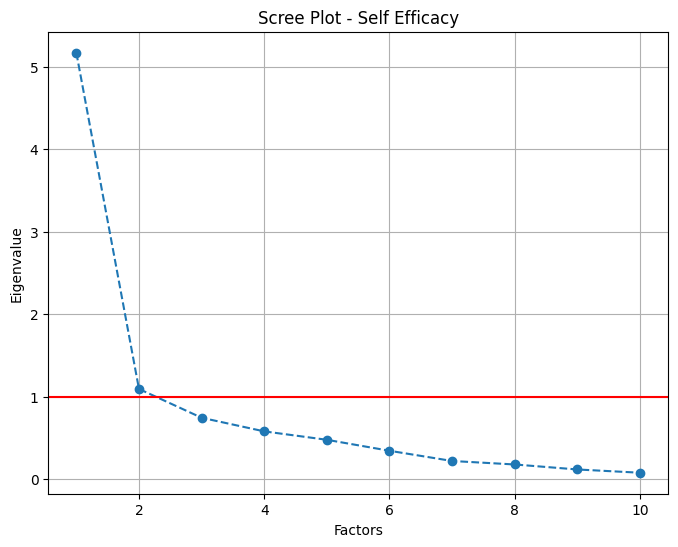

In [7]:
SE_df = df_clean.iloc[:, variables["Self Efficacy"]].astype(float)

pca = PCA()
pca.fit(SE_df)

# Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o', linestyle='--')
plt.title('Scree Plot - Self Efficacy')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-')
plt.grid(True)
plt.show()

### EFA

In [8]:
cut_off = 0.4

# EFA executions with 2 factors (based on the Scree Plot)
fa = FactorAnalyzer(n_factors=2, rotation=None)
fa_fit = fa.fit(SE_df)

# Loadings extraction
loadings = fa.loadings_

# We apply the cut-off to select the columns to keep
columns_to_keep = np.any(np.abs(loadings) >= cut_off, axis=1)
filtered_self_efficacy_data = SE_df.loc[:, columns_to_keep]

acronyms = df.iloc[0, variables["Self Efficacy"]]
filtered_acronyms = acronyms[columns_to_keep]

# Stampare gli acronimi filtrati
filtered_acronyms

# Results
print("Loadings: \n", loadings)
print("Columns to keep:", filtered_acronyms.values.tolist())

Loadings: 
 [[ 0.70026764 -0.35272342]
 [ 0.68073584  0.04948539]
 [ 0.78920628 -0.11390451]
 [ 0.68641854 -0.06298465]
 [ 0.79375592 -0.23163766]
 [ 0.87397887 -0.080157  ]
 [ 0.80420644 -0.26045256]
 [ 0.52543454  0.30091562]
 [ 0.68024715  0.75179606]
 [ 0.66081241  0.21231536]]
Columns to keep: ['SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7', 'SE8', 'SE9', 'SE10']


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [9]:
#Factor Results
loadings_df = pd.DataFrame(loadings, index=acronyms, columns=['Factor 1', 'Factor 2'])

acronyms.index = loadings_df.index

factor_1_acronyms = acronyms[np.abs(loadings_df['Factor 1']) > np.abs(loadings_df['Factor 2'])].tolist()
factor_2_acronyms = acronyms[np.abs(loadings_df['Factor 2']) > np.abs(loadings_df['Factor 1'])].tolist()

print("Factor 1:", factor_1_acronyms)
print("Factor 2:", factor_2_acronyms)

Factor 1: ['SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7', 'SE8', 'SE10']
Factor 2: ['SE9']


###Tests

In [10]:
# Creare i dataframes per SE_Fac_1 e SE_Fac_2
SE_Fac_1_df = df_clean.iloc[:, variables["Self Efficacy"]].iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 9]]
SE_Fac_2_df = df_clean.iloc[:, variables["Self Efficacy"]].iloc[:, [8]]

###################################### Factor 1 ######################################
modes = df_clean.iloc[:, -1]

mode_1_data = SE_Fac_1_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = SE_Fac_1_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = SE_Fac_1_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 1
kruskal_test_result_fac_1 = kruskal(
    *[SE_Fac_1_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 1
mannwhitney_vr_vs_presence_fac_1 = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote_fac_1 = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence_fac_1 = mannwhitneyu(mode_2_data, mode_1_data)

###################################### Factor 2 ######################################
mode_1_data_fac_2 = SE_Fac_2_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data_fac_2 = SE_Fac_2_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data_fac_2 = SE_Fac_2_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 2
kruskal_test_result_fac_2 = kruskal(
    *[SE_Fac_2_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 2
mannwhitney_vr_vs_presence_fac_2 = mannwhitneyu(mode_3_data_fac_2, mode_1_data_fac_2)
mannwhitney_vr_vs_remote_fac_2 = mannwhitneyu(mode_3_data_fac_2, mode_2_data_fac_2)
mannwhitney_remote_vs_presence_fac_2 = mannwhitneyu(mode_2_data_fac_2, mode_1_data_fac_2)


###################################### Results Factor 1 ######################################
print("\n----------------------Factor 1-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_1.pvalue, "| statistic =", kruskal_test_result_fac_1.statistic, " -> ", significant(kruskal_test_result_fac_1.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_1.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_1.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_1.pvalue))


###################################### Results Factor 2 ######################################
print("\n----------------------Factor 2-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_2.pvalue, "| statistic =", kruskal_test_result_fac_2.statistic, " -> ", significant(kruskal_test_result_fac_2.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_2.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_2.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_2.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_2.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_2.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_2.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_2.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_2.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_2.pvalue))



----------------------Factor 1-----------------------
Kruskal-Wallis test result:
pvalue = 0.03563489651553098 | statistic = 6.668859764089118  ->  Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.33267195884548173 | ustatistic =  38.0  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.10020848496324515 | ustatistic =  70.5  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.016571159096613195 | ustatistic =  20.0  ->  Significant

----------------------Factor 2-----------------------
Kruskal-Wallis test result:
pvalue = 0.48547429852061486 | statistic = 1.4452578616352072  ->  Not Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.6351171542413605 | ustatistic =  56.5  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.22208529349305706 | ustatistic =  65.5  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.5976920488084783 | usta

### Post-hoc
Only for significant factors from the Kurskal-Wallis test results

In [ ]:
SE_Fac_1_df['Type'] = modes.values.tolist()

long_df = SE_Fac_1_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')
dunn_test_result = sp.posthoc_dunn(long_df, group_col='Type', val_col='Value', p_adjust='bonferroni')

dunn_test_result

,Presence,Remote,VR
Presence,1.000000e+00,2.286125e-07,0.143391
Remote,2.286125e-07,1.000000e+00,0.002046
VR,1.433908e-01,2.045937e-03,1.000000


## Immersiveness

We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Immersiveness (IM) variable.

IM answers are on a scale from 1 to 5.

### Scree Plot to decide number of factors

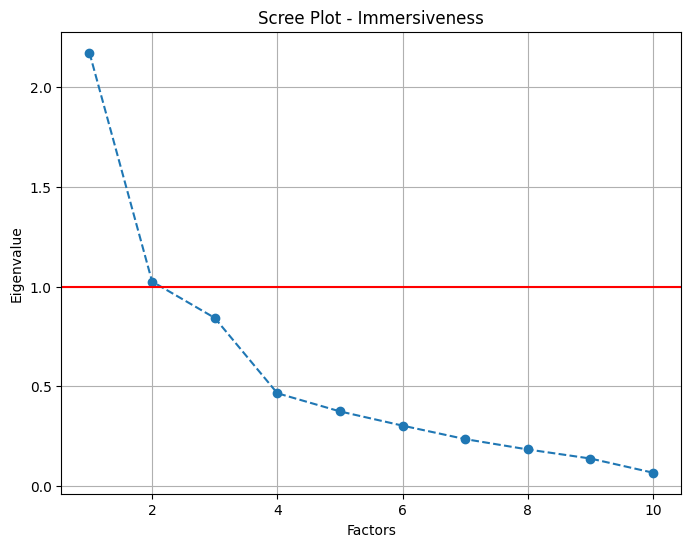

In [ ]:
IM_df = df_clean.iloc[:, variables["Immersiveness"]].astype(float)

pca = PCA()
pca.fit(IM_df)

# Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o', linestyle='--')
plt.title('Scree Plot - Immersiveness')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-')
plt.grid(True)
plt.show()

### EFA

In [ ]:
cut_off = 0.4

# EFA executions with 2 factors (based on the Scree Plot)
fa = FactorAnalyzer(n_factors=2, rotation=None)
fa_fit = fa.fit(IM_df)

# Loadings extraction
loadings = fa.loadings_

# We apply the cut-off to select the columns to keep
columns_to_keep = np.any(np.abs(loadings) >= cut_off, axis=1)
filtered_self_efficacy_data = IM_df.loc[:, columns_to_keep]

acronyms = df.iloc[0, variables["Immersiveness"]]
filtered_acronyms = acronyms[columns_to_keep]

# Stampare gli acronimi filtrati
filtered_acronyms

# Results
print("Loadings: \n", loadings)
print("Columns to keep:", filtered_acronyms.values.tolist())

Loadings: 
 [[ 0.36355224  0.59007877]
 [ 0.53619845  0.454775  ]
 [ 0.60881779  0.19676151]
 [ 0.65883914  0.08256654]
 [ 0.08443812  0.08137997]
 [ 0.73258383 -0.68154133]
 [ 0.71603784  0.02900435]
 [ 0.55867241 -0.05901146]
 [ 0.59849097 -0.37840764]
 [ 0.47410929  0.20780847]]
Columns to keep: ['IM1', 'IM2', 'IM3', 'IM4', 'IM6', 'IM7', 'IM8', 'IM9', 'IM10']


In [ ]:
#Factor Results
loadings_df = pd.DataFrame(loadings, index=acronyms, columns=['Factor 1', 'Factor 2'])

acronyms.index = loadings_df.index

factor_1_acronyms = acronyms[np.abs(loadings_df['Factor 1']) > np.abs(loadings_df['Factor 2'])].tolist()
factor_2_acronyms = acronyms[np.abs(loadings_df['Factor 2']) > np.abs(loadings_df['Factor 1'])].tolist()

print("Factor 1:", factor_1_acronyms)
print("Factor 2:", factor_2_acronyms)

Factor 1: ['IM2', 'IM3', 'IM4', 'IM5', 'IM6', 'IM7', 'IM8', 'IM9', 'IM10']
Factor 2: ['IM1']


### Tests

In [ ]:
# Creare i dataframes per IM_Fac_1 e IM_Fac_2
IM_Fac_1_df = df_clean.iloc[:, variables["Immersiveness"]].iloc[:, [1, 2, 3, 5, 6, 7, 8, 9]]
IM_Fac_2_df = df_clean.iloc[:, variables["Immersiveness"]].iloc[:, [0]]

###################################### Factor 1 ######################################
modes = df_clean.iloc[:, -1]

mode_1_data = IM_Fac_1_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = IM_Fac_1_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = IM_Fac_1_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 1
kruskal_test_result_fac_1 = kruskal(
    *[IM_Fac_1_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 1
mannwhitney_vr_vs_presence_fac_1 = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote_fac_1 = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence_fac_1 = mannwhitneyu(mode_2_data, mode_1_data)

###################################### Factor 2 ######################################
mode_1_data_fac_2 = IM_Fac_2_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data_fac_2 = IM_Fac_2_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data_fac_2 = IM_Fac_2_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 2
kruskal_test_result_fac_2 = kruskal(
    *[IM_Fac_2_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 2
mannwhitney_vr_vs_presence_fac_2 = mannwhitneyu(mode_3_data_fac_2, mode_1_data_fac_2)
mannwhitney_vr_vs_remote_fac_2 = mannwhitneyu(mode_3_data_fac_2, mode_2_data_fac_2)
mannwhitney_remote_vs_presence_fac_2 = mannwhitneyu(mode_2_data_fac_2, mode_1_data_fac_2)


###################################### Results Factor 1 ######################################
print("\n----------------------Factor 1-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_1.pvalue, "| statistic =", kruskal_test_result_fac_1.statistic, " -> ", significant(kruskal_test_result_fac_1.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_1.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_1.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_1.pvalue))


###################################### Results Factor 2 ######################################
print("\n----------------------Factor 2-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_2.pvalue, "| statistic =", kruskal_test_result_fac_2.statistic, " -> ", significant(kruskal_test_result_fac_2.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_2.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_2.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_2.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_2.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_2.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_2.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_2.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_2.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_2.pvalue))



----------------------Factor 1-----------------------
Kruskal-Wallis test result:
pvalue = 0.5840563026694803 | statistic = 1.0755157842406227  ->  Not Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.6662641183417715 | ustatistic =  44.0  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.42889229302197374 | ustatistic =  60.0  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.39801265291590204 | ustatistic =  39.0  ->  Not Significant

----------------------Factor 2-----------------------
Kruskal-Wallis test result:
pvalue = 0.027284436009137596 | statistic = 7.202877697841736  ->  Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.01218156179654489 | ustatistic =  18.0  ->  Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.19463302762900425 | ustatistic =  33.0  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.12240065918469185 | usta

### Post-hoc
Only for significant factors from the Kurskal-Wallis test results

In [ ]:
IM_Fac_2_df['Type'] = modes.values.tolist()

long_df = IM_Fac_2_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')
dunn_test_result = sp.posthoc_dunn(long_df, group_col='Type', val_col='Value', p_adjust='bonferroni')

dunn_test_result

,Presence,Remote,VR
Presence,1.000000,0.465453,0.021941
Remote,0.465453,1.000000,0.622318
VR,0.021941,0.622318,1.000000


## Affective Engagement

We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Affective Engagement (AE) variable.

AE answers are on a scale from 1 to 7.

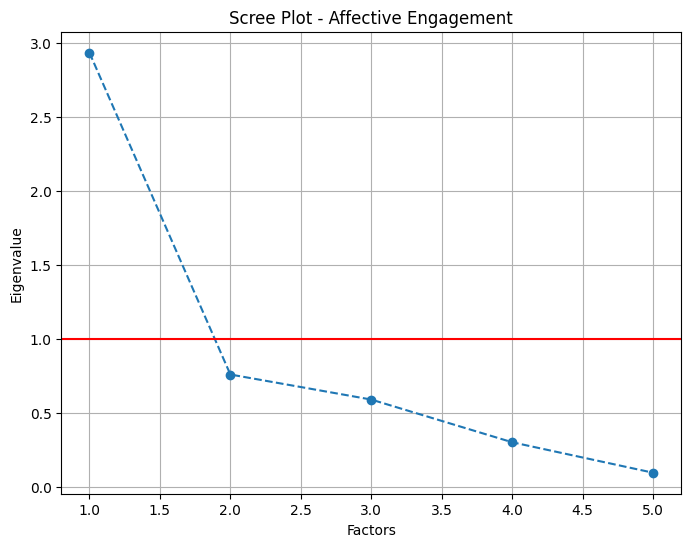

In [ ]:
AE_df = df_clean.iloc[:, variables["Affective Engagement"]].astype(float)

pca = PCA()
pca.fit(AE_df)

# Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o', linestyle='--')
plt.title('Scree Plot - Affective Engagement')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-')
plt.grid(True)
plt.show()

### EFA

In [ ]:
cut_off = 0.4

# EFA executions with 1 factor (based on the Scree Plot)
fa = FactorAnalyzer(n_factors=1, rotation=None)
fa_fit = fa.fit(AE_df)

# Loadings extraction
loadings = fa.loadings_

# We apply the cut-off to select the columns to keep
columns_to_keep = np.any(np.abs(loadings) >= cut_off, axis=1)
filtered_self_efficacy_data = AE_df.loc[:, columns_to_keep]

acronyms = df.iloc[0, variables["Affective Engagement"]]
filtered_acronyms = acronyms[columns_to_keep]

# Stampare gli acronimi filtrati
filtered_acronyms

# Results
print("Loadings: \n", loadings)
print("Columns to keep:", filtered_acronyms.values.tolist())

Loadings: 
 [[-0.50848634]
 [-0.76463916]
 [-1.00893332]
 [-0.65069161]
 [-0.51206209]]
Columns to keep: ['AE1', 'AE2', 'AE3', 'AE4', 'AE5']


In [ ]:
#Factor Results
loadings_df = pd.DataFrame(loadings, index=acronyms, columns=['Factor 1'])

acronyms.index = loadings_df.index

factor_1_acronyms = ['AE1', 'AE2', 'AE3', 'AE4', 'AE5']
#factor_2_acronyms = acronyms[np.abs(loadings_df['Factor 2']) > np.abs(loadings_df['Factor 1'])].tolist()

print("Factor 1:", factor_1_acronyms)
#print("Factor 2:", factor_2_acronyms)

Factor 1: ['AE1', 'AE2', 'AE3', 'AE4', 'AE5']


### Tests

In [ ]:
AE_Fac_1_df = df_clean.iloc[:, variables["Affective Engagement"]].iloc[:, [0, 1, 2, 3, 4]]

###################################### Factor 1 ######################################
modes = df_clean.iloc[:, -1]

mode_1_data = AE_Fac_1_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = AE_Fac_1_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = AE_Fac_1_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 1
kruskal_test_result_fac_1 = kruskal(
    *[AE_Fac_1_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 1
mannwhitney_vr_vs_presence_fac_1 = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote_fac_1 = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence_fac_1 = mannwhitneyu(mode_2_data, mode_1_data)


###################################### Results Factor 1 ######################################
print("\n----------------------Factor 1-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_1.pvalue, "| statistic =", kruskal_test_result_fac_1.statistic, " -> ", significant(kruskal_test_result_fac_1.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_1.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_1.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_1.pvalue))



----------------------Factor 1-----------------------
Kruskal-Wallis test result:
pvalue = 0.00037031077256957553 | statistic = 15.802335958005246  ->  Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.0024245994199182485 | ustatistic =  86.5  ->  Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.00014509841181584737 | ustatistic =  96.0  ->  Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.7212167743461041 | ustatistic =  45.5  ->  Not Significant


### Post-hoc
Only for significant factors of Kruskal-Wallis test results

In [ ]:
AE_Fac_1_df['Type'] = modes.values.tolist()

long_df = AE_Fac_1_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')
dunn_test_result = sp.posthoc_dunn(long_df, group_col='Type', val_col='Value', p_adjust='bonferroni')

dunn_test_result

,Presence,Remote,VR
Presence,1.000000,1.000000e+00,1.466876e-06
Remote,1.000000,1.000000e+00,1.952863e-08
VR,0.000001,1.952863e-08,1.000000e+00


## Behavioral Engagement Compliance

We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Affective Engagement (BE1) variable.

BE1 answers are on a scale from 1 to 7.

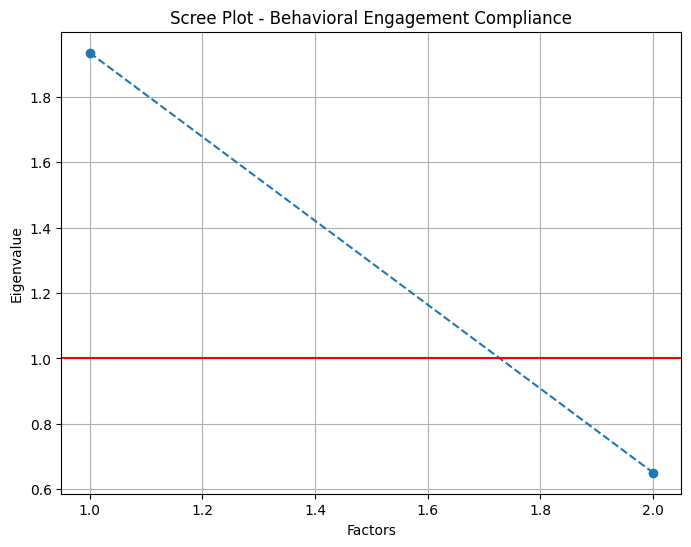

In [ ]:
BE1_df = df_clean.iloc[:, variables["Behavioral Engagement Compliance"]].astype(float)

pca = PCA()
pca.fit(BE1_df)

# Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o', linestyle='--')
plt.title('Scree Plot - Behavioral Engagement Compliance')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-')
plt.grid(True)
plt.show()

### EFA

In [ ]:
cut_off = 0.4

# EFA executions with 1 factor (based on the Scree Plot)
fa = FactorAnalyzer(n_factors=1, rotation=None)
fa_fit = fa.fit(BE1_df)

# Loadings extraction
loadings = fa.loadings_

# We apply the cut-off to select the columns to keep
columns_to_keep = np.any(np.abs(loadings) >= cut_off, axis=1)
filtered_self_efficacy_data = BE1_df.loc[:, columns_to_keep]

acronyms = df.iloc[0, variables["Behavioral Engagement Compliance"]]
filtered_acronyms = acronyms[columns_to_keep]

# Stampare gli acronimi filtrati
filtered_acronyms

# Results
print("Loadings: \n", loadings)
print("Columns to keep:", filtered_acronyms.values.tolist())

Loadings: 
 [[-0.60911818]
 [-0.60911818]]
Columns to keep: ['BE1', 'BE2']


### Tests

In [ ]:
# Creare i dataframes per BE_Fac_1
BE1_Fac_1_df = df_clean.iloc[:, variables["Behavioral Engagement Compliance"]].iloc[:, [0, 1]]

###################################### Factor 1 ######################################
modes = df_clean.iloc[:, -1]

mode_1_data = BE1_Fac_1_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = BE1_Fac_1_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = BE1_Fac_1_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 1
kruskal_test_result_fac_1 = kruskal(
    *[BE1_Fac_1_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 1
mannwhitney_vr_vs_presence_fac_1 = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote_fac_1 = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence_fac_1 = mannwhitneyu(mode_2_data, mode_1_data)


###################################### Results Factor 1 ######################################
print("\n----------------------Factor 1-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_1.pvalue, "| statistic =", kruskal_test_result_fac_1.statistic, " -> ", significant(kruskal_test_result_fac_1.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_1.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_1.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_1.pvalue))



----------------------Factor 1-----------------------
Kruskal-Wallis test result:
pvalue = 0.025375767737889687 | statistic = 7.3479211727949965  ->  Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.17980713725587993 | ustatistic =  33.0  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.3115148035577098 | ustatistic =  63.5  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.005281069645217485 | ustatistic =  14.0  ->  Significant


### Post-hoc

In [ ]:
BE1_Fac_1_df['Type'] = modes.values.tolist()

long_df = BE1_Fac_1_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')
dunn_test_result = sp.posthoc_dunn(long_df, group_col='Type', val_col='Value', p_adjust='bonferroni')

dunn_test_result

,Presence,Remote,VR
Presence,1.000000,0.007208,0.168384
Remote,0.007208,1.000000,0.781391
VR,0.168384,0.781391,1.000000


## Behavioral Engagement Effort Class Participation

We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Affective Engagement (BE2) variable.

BE2 answers are on a scale from 1 to 7.

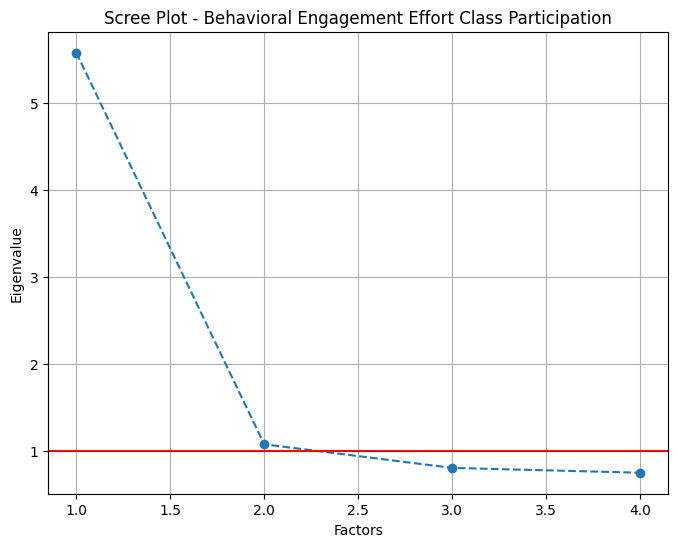

In [ ]:
BE2_df = df_clean.iloc[:, variables["Behavioral Engagement Effort Class Participation"]].astype(float)

pca = PCA()
pca.fit(BE2_df)

# Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o', linestyle='--')
plt.title('Scree Plot - Behavioral Engagement Effort Class Participation')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-')
plt.grid(True)
plt.show()

### EFA

In [ ]:
cut_off = 0.4

# EFA executions with 1 factor (based on the Scree Plot)
fa = FactorAnalyzer(n_factors=2, rotation=None)
fa_fit = fa.fit(BE2_df)

# Loadings extraction
loadings = fa.loadings_

# We apply the cut-off to select the columns to keep
columns_to_keep = np.any(np.abs(loadings) >= cut_off, axis=1)
filtered_self_efficacy_data = BE2_df.loc[:, columns_to_keep]

acronyms = df.iloc[0, variables["Behavioral Engagement Effort Class Participation"]]
filtered_acronyms = acronyms[columns_to_keep]

# Stampare gli acronimi filtrati
filtered_acronyms

# Results
print("Loadings: \n", loadings)
print("Columns to keep:", filtered_acronyms.values.tolist())

Loadings: 
 [[ 0.33553206  0.17197882]
 [ 0.71357867 -0.18452353]
 [ 0.76654387  0.018719  ]
 [ 0.83201711  0.07165563]]
Columns to keep: ['BE4', 'BE5', 'BE6']


In [ ]:
#Factor Results
loadings_df = pd.DataFrame(loadings, index=acronyms, columns=['Factor 1', 'Factor 2'])

acronyms.index = loadings_df.index

factor_1_acronyms = acronyms[np.abs(loadings_df['Factor 1']) > np.abs(loadings_df['Factor 2'])].tolist()
factor_2_acronyms = acronyms[np.abs(loadings_df['Factor 2']) > np.abs(loadings_df['Factor 1'])].tolist()

print("Factor 1:", factor_1_acronyms)
print("Factor 2:", factor_2_acronyms)

Factor 1: ['BE3', 'BE4', 'BE5', 'BE6']
Factor 2: []


### Tests

In [ ]:
# Creare i dataframes per BE_Fac_1
BE2_Fac_1_df = df_clean.iloc[:, variables["Behavioral Engagement Effort Class Participation"]].iloc[:, [1, 2, 3]]

###################################### Factor 1 ######################################
modes = df_clean.iloc[:, -1]

mode_1_data = BE2_Fac_1_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = BE2_Fac_1_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = BE2_Fac_1_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 1
kruskal_test_result_fac_1 = kruskal(
    *[BE2_Fac_1_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 1
mannwhitney_vr_vs_presence_fac_1 = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote_fac_1 = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence_fac_1 = mannwhitneyu(mode_2_data, mode_1_data)


###################################### Results Factor 1 ######################################
print("\n----------------------Factor 1-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_1.pvalue, "| statistic =", kruskal_test_result_fac_1.statistic, " -> ", significant(kruskal_test_result_fac_1.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_1.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_1.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_1.pvalue))



----------------------Factor 1-----------------------
Kruskal-Wallis test result:
pvalue = 0.03126612859582092 | statistic = 6.930439841750058  ->  Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.9060640271390608 | ustatistic =  48.0  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.014466920485365554 | ustatistic =  82.0  ->  Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.04614014707290848 | ustatistic =  23.5  ->  Significant


### Post-hoc

In [ ]:
BE2_Fac_1_df['Type'] = modes.values.tolist()

long_df = BE2_Fac_1_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')
dunn_test_result = sp.posthoc_dunn(long_df, group_col='Type', val_col='Value', p_adjust='bonferroni')

dunn_test_result

,Presence,Remote,VR
Presence,1.000000,0.004741,1.000000
Remote,0.004741,1.000000,0.002745
VR,1.000000,0.002745,1.000000


## Reverse Disengagement
We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Reverse Disengagement (RDE) variable.

RDE answers are on a scale from 1 to 7.

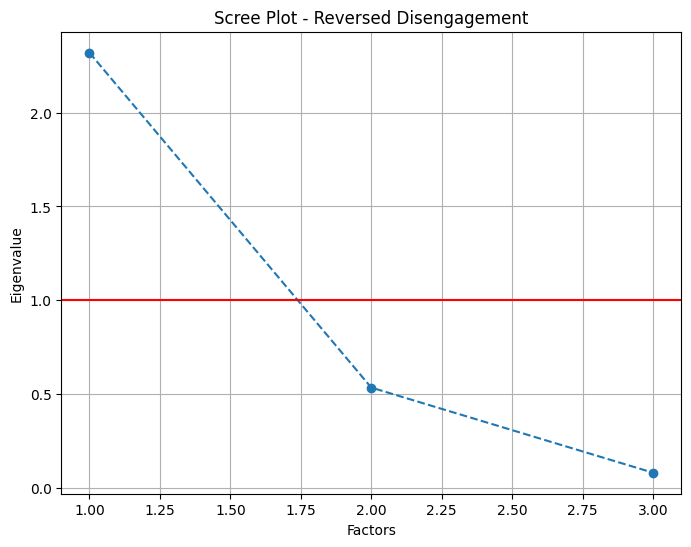

In [ ]:
RDE_df = df_clean.iloc[:, variables["Disengagement_Reversed"]].astype(float)

pca = PCA()
pca.fit(RDE_df)

# Scree plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(pca.explained_variance_)+1), pca.explained_variance_, marker='o', linestyle='--')
plt.title('Scree Plot - Reversed Disengagement')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='-')
plt.grid(True)
plt.show()

### EFA

In [ ]:
cut_off = 0.4

# EFA executions with 1 factor (based on the Scree Plot)
fa = FactorAnalyzer(n_factors=1, rotation=None)
fa_fit = fa.fit(RDE_df)

# Loadings extraction
loadings = fa.loadings_

# We apply the cut-off to select the columns to keep
columns_to_keep = np.any(np.abs(loadings) >= cut_off, axis=1)
filtered_self_efficacy_data = RDE_df.loc[:, columns_to_keep]

acronyms = df.iloc[0, variables["Disengagement_Reversed"]]
filtered_acronyms = acronyms[columns_to_keep]

# Stampare gli acronimi filtrati
filtered_acronyms

# Results
print("Loadings: \n", loadings)
print("Columns to keep:", filtered_acronyms.values.tolist())

Loadings: 
 [[-0.72913526]
 [-0.8469712 ]
 [-0.72443132]]
Columns to keep: ['RDE1', 'RDE2', 'RDE3']


In [ ]:
# Creare i dataframes per BE_Fac_1
RDE_Fac_1_df = df_clean.iloc[:, variables["Disengagement_Reversed"]].iloc[:, [0, 1, 2]]

###################################### Factor 1 ######################################
modes = df_clean.iloc[:, -1]

mode_1_data = RDE_Fac_1_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = RDE_Fac_1_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = RDE_Fac_1_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test for Factor 1
kruskal_test_result_fac_1 = kruskal(
    *[RDE_Fac_1_df[modes == mode].astype(float).median(axis=1) for mode in modes.unique()]
)

# Mann-Whitney U test for Factor 1
mannwhitney_vr_vs_presence_fac_1 = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote_fac_1 = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence_fac_1 = mannwhitneyu(mode_2_data, mode_1_data)


###################################### Results Factor 1 ######################################
print("\n----------------------Factor 1-----------------------")
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result_fac_1.pvalue, "| statistic =", kruskal_test_result_fac_1.statistic, " -> ", significant(kruskal_test_result_fac_1.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_presence_fac_1.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote_fac_1.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote_fac_1.statistic, " -> ", significant(mannwhitney_vr_vs_remote_fac_1.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence_fac_1.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence_fac_1.statistic, " -> ", significant(mannwhitney_remote_vs_presence_fac_1.pvalue))



----------------------Factor 1-----------------------
Kruskal-Wallis test result:
pvalue = 0.32011216766232525 | statistic = 2.2781676413255276  ->  Not Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.32484148949356106 | ustatistic =  37.5  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.1674920063164992 | ustatistic =  33.0  ->  Not Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.6866964472596304 | ustatistic =  55.0  ->  Not Significant


## NPS - Net Promoter Score
We perform the EFA to select the columns to consider for the tests.

Then, we perform Mann-Whitney U and the Kruskal-Wallis tests on the Net Promoter Score (NPS) variable.

NPS answers are on a scale from 1 to 10.

### Tests

In [ ]:
# The first row contains the acronyms, so we do not consider it for the tests
df_clean = df.iloc[1:].reset_index(drop=True)

# Estrazione delle colonne relative al "Learning Outcome" dalla lista di indici forniti
NPS_df = df_clean.iloc[:, variables["NPS"]]

# We take the mode from the last column of the dataset
modes = df_clean.iloc[:, -1]

mode_1_data = NPS_df[modes == 'Presence'].astype(float).median(axis=1)
mode_2_data = NPS_df[modes == 'Remote'].astype(float).median(axis=1)
mode_3_data = NPS_df[modes == 'VR'].astype(float).median(axis=1)

# Kruskal-Wallis test
kruskal_test_result = kruskal(
    *[NPS_df[modes == mode].astype(float).values.flatten() for mode in modes.unique()]
)

# Mann-Whitney U test
mannwhitney_vr_vs_presence = mannwhitneyu(mode_3_data, mode_1_data)
mannwhitney_vr_vs_remote = mannwhitneyu(mode_3_data, mode_2_data)
mannwhitney_remote_vs_presence = mannwhitneyu(mode_2_data, mode_1_data)

# Results
print("Kruskal-Wallis test result:")
print("pvalue =", kruskal_test_result.pvalue, "| statistic =", kruskal_test_result.statistic, " -> ", significant(kruskal_test_result.pvalue))

print("\n\nMann-Whitney U test results VR vs Presence: ")
print("pvalue = ", mannwhitney_vr_vs_presence.pvalue, "| ustatistic = ", mannwhitney_vr_vs_presence.statistic, " -> ", significant(mannwhitney_vr_vs_presence.pvalue))
print("\n\nMann-Whitney U test results VR vs Remote:")
print("pvalue = ", mannwhitney_vr_vs_remote.pvalue, "| ustatistic = ", mannwhitney_vr_vs_remote.statistic, " -> ", significant(mannwhitney_vr_vs_remote.pvalue))
print("\n\nMann-Whitney U test results Remote vs Presence:")
print("pvalue = ", mannwhitney_remote_vs_presence.pvalue, "| ustatistic = ", mannwhitney_remote_vs_presence.statistic, " -> ", significant(mannwhitney_remote_vs_presence.pvalue))


Kruskal-Wallis test result:
pvalue = 0.05885873799932063 | statistic = 5.66522995424994  ->  Not Significant


Mann-Whitney U test results VR vs Presence: 
pvalue =  0.17082802961138166 | ustatistic =  67.5  ->  Not Significant


Mann-Whitney U test results VR vs Remote:
pvalue =  0.016950109271553188 | ustatistic =  81.0  ->  Significant


Mann-Whitney U test results Remote vs Presence:
pvalue =  0.47105774751013973 | ustatistic =  40.5  ->  Not Significant


### Post-hoc

In [ ]:
NPS_df['Type'] = modes.values.tolist()

long_df = NPS_df.melt(id_vars=['Type'], var_name='Variable', value_name='Value')
dunn_test_result = sp.posthoc_dunn(long_df, group_col='Type', val_col='Value', p_adjust='bonferroni')

dunn_test_result

<ipython-input-75-eb4fb6187df7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NPS_df['Type'] = modes.values.tolist()


,Presence,Remote,VR
Presence,1.000000,0.385949,1.000000
Remote,0.385949,1.000000,0.048558
VR,1.000000,0.048558,1.000000
